# Notebook 2: Visualizations and Outliers

**Course:** Data Engineering - Unsupervised Learning Project  
**University:** Bar-Ilan University, Spring 2026  
**Dataset:** NYC PLUTO - 858,644 lots/buildings across New York City  

## Sections Covered
- [x] **Section 4** - Descriptive Statistics, Impossible Values, and Outlier Detection
- [x] **Section 5** - Visualizations: Boxplots, Histograms, Scatter Plots, Correlation

## Research Question
> *How can we build, from the physical, functional and geographical characteristics
> of the PLUTO dataset, an unsupervised segmentation of NYC buildings to identify
> homogeneous urban profiles and analyze their distribution across the five boroughs?*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os

print("Loading data...") 

Loading data...


In [2]:
local_path = 'data/raw/pluto_working_copy.csv'
url = 'https://data.cityofnewyork.us/api/views/64uk-42ks/rows.csv?accessType=DOWNLOAD'

if os.path.exists(local_path):
    print('Loading dataset from local working copy...')
    df = pd.read_csv(local_path, low_memory=False)
else:
    print('Local working copy not found. Downloading from NYC Open Data...')
    df = pd.read_csv(url, low_memory=False)
    os.makedirs('data/raw', exist_ok=True)
    df.to_csv(local_path, index=False)
    print('Working copy saved.')

os.makedirs('reports/figures', exist_ok=True)

# The raw CSV uses a Narrow No-Break Space (U+202F) as a thousands separator.
# pandas 3.x reads these as dtype 'str', so we use is_string_dtype().
numeric_cols = [
    'yearbuilt', 'lotarea', 'bldgarea', 'numfloors',
    'lotfront', 'lotdepth', 'unitstotal', 'unitsres',
    'resarea', 'comarea', 'officearea', 'retailarea',
    'garagearea', 'strgearea',
]
for col in numeric_cols:
    if col in df.columns and pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loading dataset from local working copy...


Dataset loaded: 858,644 rows, 101 columns


In [3]:
# ================================================
# SELECTED FEATURES
# 14 numerical + 2 categorical
# ================================================
numerical_features = [
    'lotarea',    # Land lot area
    'bldgarea',   # Total building area
    'comarea',    # Commercial area
    'resarea',    # Residential area
    'officearea', # Office area
    'retailarea', # Retail area
    'garagearea', # Garage area
    'strgearea',  # Storage area
    'numfloors',  # Number of floors
    'unitstotal', # Total number of units
    'unitsres',   # Residential units
    'lotfront',   # Lot frontage
    'lotdepth',   # Lot depth
    'yearbuilt'   # Year of construction
]

categorical_features = [
    'landuse',  # Land use category
    'borough'   # NYC borough
]

print(f"Numerical features   : {len(numerical_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"\nAll numerical features :")
for f in numerical_features:
    print(f"  → {f}")

Numerical features   : 14
Categorical features : 2

All numerical features :
  → lotarea
  → bldgarea
  → comarea
  → resarea
  → officearea
  → retailarea
  → garagearea
  → strgearea
  → numfloors
  → unitstotal
  → unitsres
  → lotfront
  → lotdepth
  → yearbuilt


## Step 1 - Descriptive Statistics
We compute 8 statistics for each of the 14 numerical features.

**Why all 14 features here?**
Descriptive statistics are cheap to compute.
We run them on everything first to get a complete picture.
Only after seeing the results do we decide where to focus.

**The most important signal: Mean vs Median**
- If Mean ≈ Median → symmetric distribution, no major problem
- If Mean >> Median → extreme values are pulling the average up → outlier problem

**What is Skewness?**
Skewness measures how asymmetric a distribution is.
- Skewness > 1 or < -1 → significant asymmetry
- Skewness > 10 → log transformation required before K-Means

**What are Zeros %?**
A high zero percentage is not always a problem.
- `comarea = 0` → normal, most buildings are residential
- `yearbuilt = 0` → impossible, treated as hidden missing value

In [4]:
# ================================================
# DESCRIPTIVE STATISTICS - All 14 numerical features
# ================================================

# Compute basic statistics
stats = df[numerical_features].describe().T

# Add 3 extra columns critical for K-Means analysis
stats['missing_%'] = (
    df[numerical_features].isnull().sum() / len(df) * 100
).round(1)

stats['zeros_%'] = (
    (df[numerical_features] == 0).sum() / len(df) * 100
).round(1)

stats['skewness'] = df[numerical_features].skew().round(2)

# Keep only the most useful columns
stats = stats[[
    'mean', '50%', 'min', 'max',
    'std', 'missing_%', 'zeros_%', 'skewness'
]]

# Rename for clarity
stats.columns = [
    'Mean', 'Median', 'Min', 'Max',
    'Std Dev', 'Missing %', 'Zeros %', 'Skewness'
]

print("===== DESCRIPTIVE STATISTICS - 14 FEATURES =====\n")
print(stats.round(2))

===== DESCRIPTIVE STATISTICS - 14 FEATURES =====

               Mean  Median  Min          Max    Std Dev  Missing %  Zeros %  \
lotarea     8102.34  2523.0  0.0  214378390.0  372222.31        0.1      0.0   
bldgarea    6713.17  2028.0  0.0   24000000.0   61106.11        0.0      4.8   
comarea     2251.21     0.0  0.0   24000000.0   51847.52        5.4     81.9   
resarea     4490.50  1760.0  0.0   13211398.0   32175.69        5.4      5.8   
officearea   833.91     0.0  0.0    7167001.0   23569.91        5.4     91.5   
retailarea   362.66     0.0  0.0    2192088.0    6485.37        5.4     87.1   
garagearea   162.85     0.0  0.0    2677430.0    6075.75        5.4     93.4   
strgearea    103.23     0.0  0.0    1757298.0    3983.43        5.4     93.7   
numfloors     12.61     2.0  0.0      34287.0      56.13        4.9      0.0   
unitstotal     4.81     2.0  0.0      13921.0      40.47        0.1      5.0   
unitsres       4.37     2.0  0.0      10914.0      34.29        0.1   

## Step 2 - Impossible Values Detection
We check for values that cannot physically exist in reality.

**Why this matters for K-Means:**
If `yearbuilt = 0` stays in the dataset, K-Means will create
a cluster of "buildings constructed in year 0" that does not exist.
This produces a fake urban profile with no real-world meaning.

**Why we do NOT check comarea, resarea, garagearea for zeros:**
A zero in these features is completely normal.
A residential building has no commercial area → comarea = 0 is correct.
Flagging these as impossible would be wrong.

We only check features where 0 is physically impossible:
- `lotarea` = 0 → a land lot must have an area
- `bldgarea` = 0 → a building must have an area
- `numfloors` = 0 → a building must have at least 1 floor
- `lotfront` = 0 → a lot must have a frontage
- `lotdepth` = 0 → a lot must have a depth
- `yearbuilt` = 0 → a building cannot be built in year 0

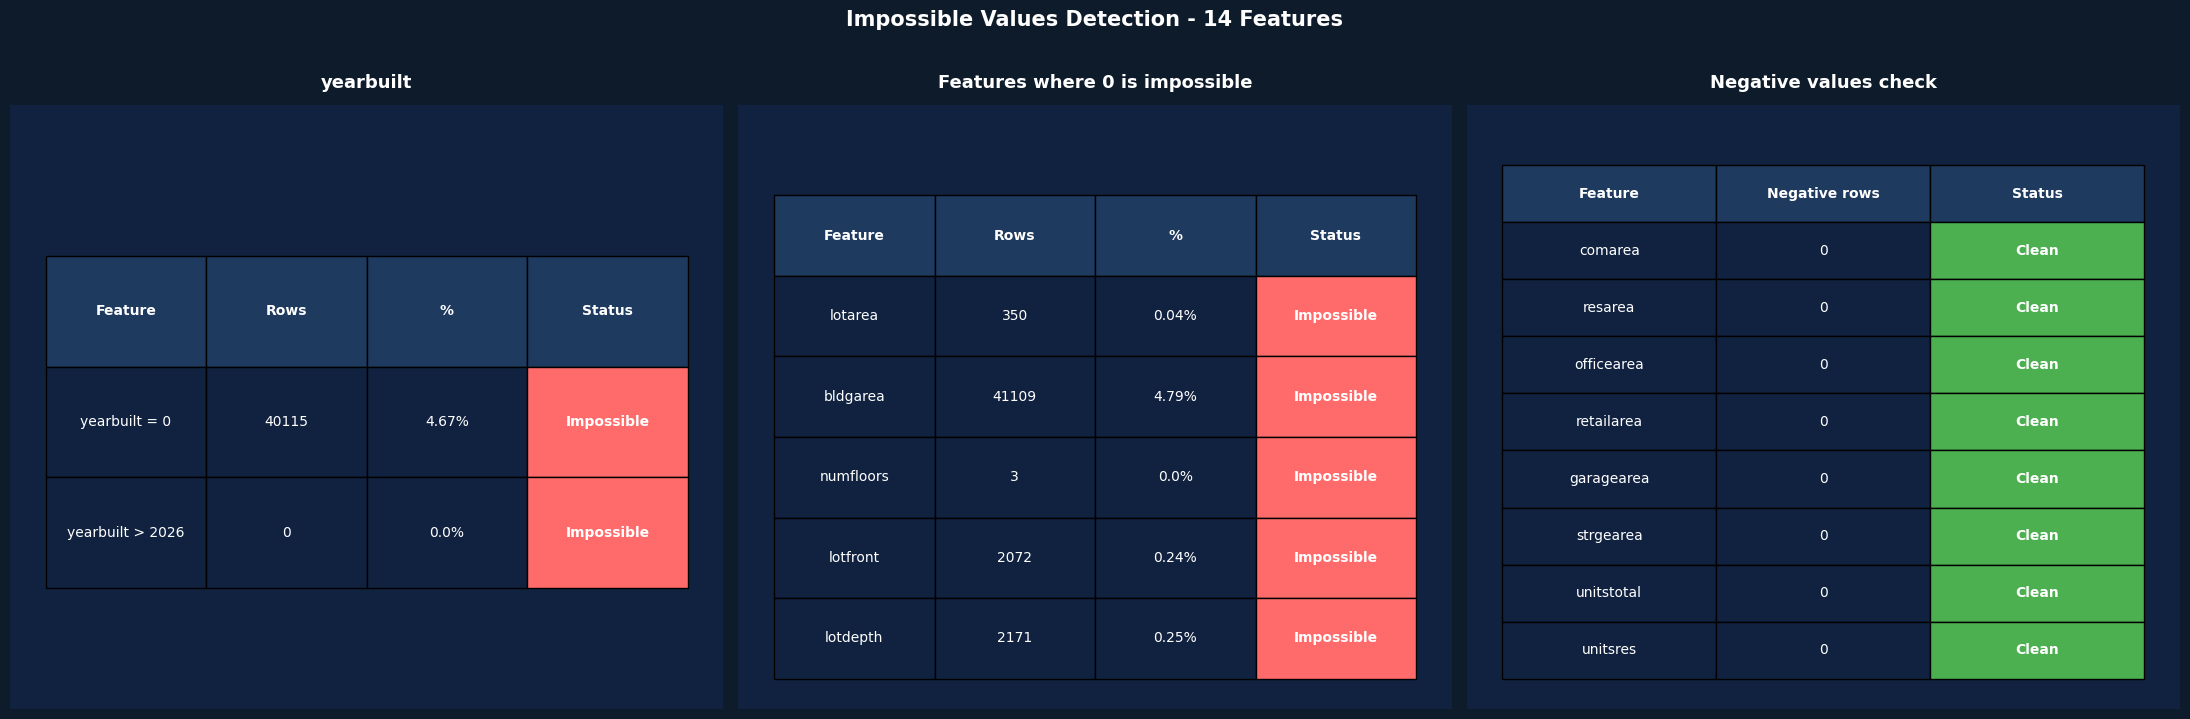

In [5]:
# ================================================
# IMPOSSIBLE VALUES DETECTION - Visual Tables
# ================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor('#0D1B2A')
plt.subplots_adjust(wspace=0.12)

def add_rounded_box(ax):
    ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
        (0.0, 0.0), 1.0, 1.0,
        boxstyle="round,pad=0.03",
        transform=ax.transAxes,
        facecolor='#112240',
        edgecolor='#2196F3',
        linewidth=1.5,
        zorder=0
    ))

# --- Table 1 : yearbuilt ---
zero   = (df['yearbuilt'] == 0).sum()
future = (df['yearbuilt'] > 2026).sum()
data1  = [
    ['yearbuilt = 0',    str(zero),   f"{round(zero/len(df)*100,2)}%",   'Impossible'],
    ['yearbuilt > 2026', str(future), f"{round(future/len(df)*100,2)}%", 'Impossible'],
]
axes[0].axis('off')
axes[0].set_facecolor('#0D1B2A')
add_rounded_box(axes[0])
t1 = axes[0].table(
    cellText=data1,
    colLabels=['Feature', 'Rows', '%', 'Status'],
    cellLoc='center', loc='center',
    bbox=[0.05, 0.2, 0.9, 0.55]
)
t1.auto_set_font_size(False)
t1.set_fontsize(10)
for j in range(4):
    t1[0, j].set_facecolor('#1E3A5F')
    t1[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 3):
    for j in range(4):
        t1[i, j].set_facecolor('#112240')
        t1[i, j].set_text_props(color='white')
    t1[i, 3].set_facecolor('#FF6B6B')
    t1[i, 3].set_text_props(color='white', fontweight='bold')
axes[0].set_title('yearbuilt', color='white',
                   fontweight='bold', fontsize=13, pad=12)

# --- Table 2 : Features where 0 is impossible ---
truly_impossible = ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth']
data2 = []
for col in truly_impossible:
    zeros = (df[col] == 0).sum()
    pct   = round(zeros / len(df) * 100, 2)
    data2.append([col, str(zeros), f"{pct}%", 'Impossible'])

axes[1].axis('off')
axes[1].set_facecolor('#0D1B2A')
add_rounded_box(axes[1])
t2 = axes[1].table(
    cellText=data2,
    colLabels=['Feature', 'Rows', '%', 'Status'],
    cellLoc='center', loc='center',
    bbox=[0.05, 0.05, 0.9, 0.8]
)
t2.auto_set_font_size(False)
t2.set_fontsize(10)
for j in range(4):
    t2[0, j].set_facecolor('#1E3A5F')
    t2[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(data2)+1):
    for j in range(4):
        t2[i, j].set_facecolor('#112240')
        t2[i, j].set_text_props(color='white')
    t2[i, 3].set_facecolor('#FF6B6B')
    t2[i, 3].set_text_props(color='white', fontweight='bold')
axes[1].set_title('Features where 0 is impossible',
                   color='white', fontweight='bold', fontsize=13, pad=12)

# --- Table 3 : Negative values ---
area_features = [
    'comarea', 'resarea', 'officearea',
    'retailarea', 'garagearea', 'strgearea',
    'unitstotal', 'unitsres'
]
data3 = []
for col in area_features:
    neg    = (df[col] < 0).sum()
    status = 'Problem' if neg > 0 else 'Clean'
    data3.append([col, str(neg), status])

axes[2].axis('off')
axes[2].set_facecolor('#0D1B2A')
add_rounded_box(axes[2])
t3 = axes[2].table(
    cellText=data3,
    colLabels=['Feature', 'Negative rows', 'Status'],
    cellLoc='center', loc='center',
    bbox=[0.05, 0.05, 0.9, 0.85]
)
t3.auto_set_font_size(False)
t3.set_fontsize(10)
for j in range(3):
    t3[0, j].set_facecolor('#1E3A5F')
    t3[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(data3)+1):
    for j in range(3):
        t3[i, j].set_facecolor('#112240')
        t3[i, j].set_text_props(color='white')
    if data3[i-1][2] == 'Clean':
        t3[i, 2].set_facecolor('#4CAF50')
    else:
        t3[i, 2].set_facecolor('#FF6B6B')
    t3[i, 2].set_text_props(color='white', fontweight='bold')
axes[2].set_title('Negative values check',
                   color='white', fontweight='bold', fontsize=13, pad=12)

plt.suptitle('Impossible Values Detection - 14 Features',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/02_impossible_values.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1B2A')
plt.show()

## Step 3 - Outlier Detection (IQR Method)

**Why IQR and not Standard Deviation?**
The standard deviation uses the mean as reference.
But the mean is already distorted by extreme values.
IQR uses only the middle 50% of the data → robust against extremes.

Rule:
- Q1 = 25th percentile
- Q3 = 75th percentile  
- IQR = Q3 - Q1
- Outlier if value < Q1 - 1.5×IQR **or** value > Q3 + 1.5×IQR

We run IQR on all 14 features first, then select the most relevant ones.

In [6]:
# ================================================
# OUTLIER DETECTION - IQR METHOD
# ================================================

def detect_outliers_iqr(data, column):
    Q1  = data[column].quantile(0.25)
    Q3  = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = (
        (data[column] < lower) | (data[column] > upper)
    ).sum()
    return {
        'Q1'          : round(Q1, 1),
        'Q3'          : round(Q3, 1),
        'Lower Bound' : round(lower, 1),
        'Upper Bound' : round(upper, 1),
        'Outliers #'  : n_outliers,
        'Outliers %'  : round(n_outliers / len(data) * 100, 2)
    }

# Run on all 14 features
outlier_table = pd.DataFrame({
    col: detect_outliers_iqr(df, col)
    for col in numerical_features
}).T.sort_values('Outliers %', ascending=False)

# Split : with outliers vs without
features_with_outliers = outlier_table[
    outlier_table['Outliers %'] > 1
].index.tolist()

features_clean = outlier_table[
    outlier_table['Outliers %'] <= 1
].index.tolist()

print("===== FEATURES WITH SIGNIFICANT OUTLIERS =====\n")
print(outlier_table[outlier_table['Outliers %'] > 1])

print("\n===== FEATURES WITH NO SIGNIFICANT OUTLIERS =====\n")
print(outlier_table[outlier_table['Outliers %'] <= 1])

print(f"\n→ {len(features_with_outliers)} features with outliers :")
for f in features_with_outliers:
    print(f"   → {f}")

===== FEATURES WITH SIGNIFICANT OUTLIERS =====

                Q1      Q3  Lower Bound  Upper Bound  Outliers #  Outliers %
lotdepth     100.0   157.0         14.5        242.5    204634.0       23.83
lotfront      24.0   215.0       -262.5        501.5    185813.0       21.64
numfloors      2.0     4.0         -1.0          7.0    141828.0       16.52
unitstotal     1.0     2.0         -0.5          3.5    110558.0       12.88
comarea        0.0     0.0          0.0          0.0    109314.0       12.73
unitsres       1.0     2.0         -0.5          3.5     96160.0       11.20
bldgarea    1400.0  3048.0      -1072.0       5520.0     90857.0       10.58
resarea     1264.0  2500.0       -590.0       4354.0     74429.0        8.67
lotarea     2000.0  4000.0      -1000.0       7000.0     74061.0        8.63
retailarea     0.0     0.0          0.0          0.0     64272.0        7.49
yearbuilt   1920.0  1960.0       1860.0       2020.0     50063.0        5.83
officearea     0.0     0.0  

## Step 4 - How Outliers Affect K-Means

This step directly answers the checklist requirement:
*"Consider whether outliers may affect cluster assignments,
distances between samples, and low-dimensional representations."*

**Why this step exists:**
Detecting outliers is not enough.
We must explain concretely what happens to K-Means
if these outliers are not treated.
This justifies every preprocessing decision made in the preprocessing phase.

In [7]:
# ================================================
# HOW OUTLIERS AFFECT K-MEANS
# ================================================

print("===== HOW OUTLIERS AFFECT K-MEANS =====\n")

critical = {
    'lotarea'   : 'Centroids pulled toward giant Manhattan lots',
    'bldgarea'  : 'Skyscrapers dominate all distance calculations',
    'numfloors' : 'Extreme vertical gap distorts cluster assignments',
    'unitstotal': 'Large complexes vs single homes - distances meaningless',
    'yearbuilt' : 'Impossible values create fake clusters',
    'resarea'   : 'Highly skewed - normal buildings look identical'
}

for col, impact in critical.items():
    pct = outlier_table.loc[col, 'Outliers %']
    print(f"{col:12s} → {pct}% outliers")
    print(f"             Impact : {impact}\n")

===== HOW OUTLIERS AFFECT K-MEANS =====

lotarea      → 8.63% outliers
             Impact : Centroids pulled toward giant Manhattan lots

bldgarea     → 10.58% outliers
             Impact : Skyscrapers dominate all distance calculations

numfloors    → 16.52% outliers
             Impact : Extreme vertical gap distorts cluster assignments

unitstotal   → 12.88% outliers
             Impact : Large complexes vs single homes - distances meaningless

yearbuilt    → 5.83% outliers
             Impact : Impossible values create fake clusters

resarea      → 8.67% outliers
             Impact : Highly skewed - normal buildings look identical



## Step 5 - Boxplots

**Why boxplots?**
The IQR table gives percentages. The boxplot gives visual proof.
A graph where the box is a thin line at the left edge,
with hundreds of orange dots stretching far to the right,
is more convincing than any number.

**Why these 6 features and not all 14?**

We focus on the 6 most impactful features for K-Means:
- `lotarea` → giant lots in Manhattan distort centroids
- `bldgarea` → most important physical feature, skewness 154
- `numfloors` → skyscrapers vs houses, extreme vertical gap
- `unitstotal` → large complexes vs single homes
- `yearbuilt` → contains impossible values (= 0)
- `resarea` → highly skewed, most buildings show near-zero

**Why NOT the other 8 features?**
- `comarea, officearea, retailarea, garagearea, strgearea`
  → 80-94% zeros → normal for residential buildings → not errors
- `unitsres` → correlation 0.86 with `unitstotal` → redundant
- `lotfront, lotdepth` → less critical than `lotarea`

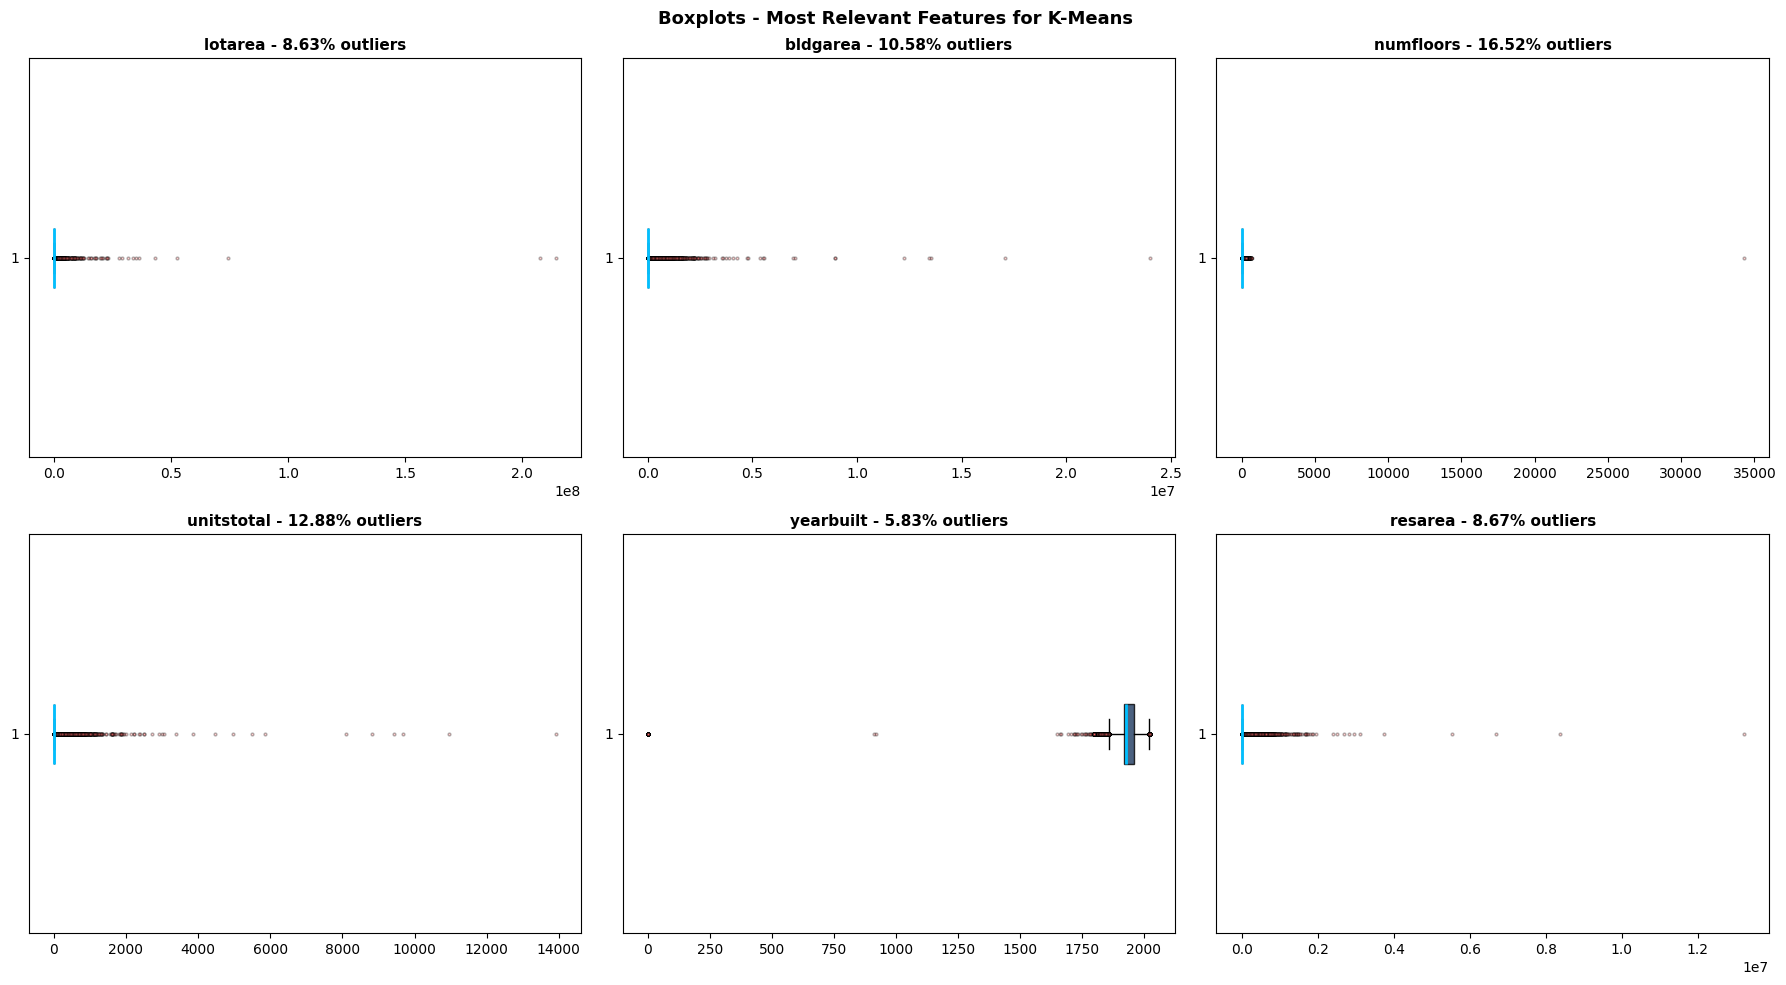

In [8]:
# ================================================
# BOXPLOTS - Most relevant features only
# We pick the features where outliers are the most
# dangerous for K-Means
# ================================================

most_relevant = [
    'lotarea',
    'bldgarea',
    'numfloors',
    'unitstotal',
    'yearbuilt',
    'resarea'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(most_relevant):
    axes[i].boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='#1E3A5F', alpha=0.8),
        medianprops=dict(color='#00BFFF', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='#FF6B6B',
                        markersize=2, alpha=0.3)
    )
    pct = outlier_table.loc[col, 'Outliers %']
    axes[i].set_title(f'{col} - {pct}% outliers',
                      fontsize=11, fontweight='bold')

plt.suptitle('Boxplots - Most Relevant Features for K-Means',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

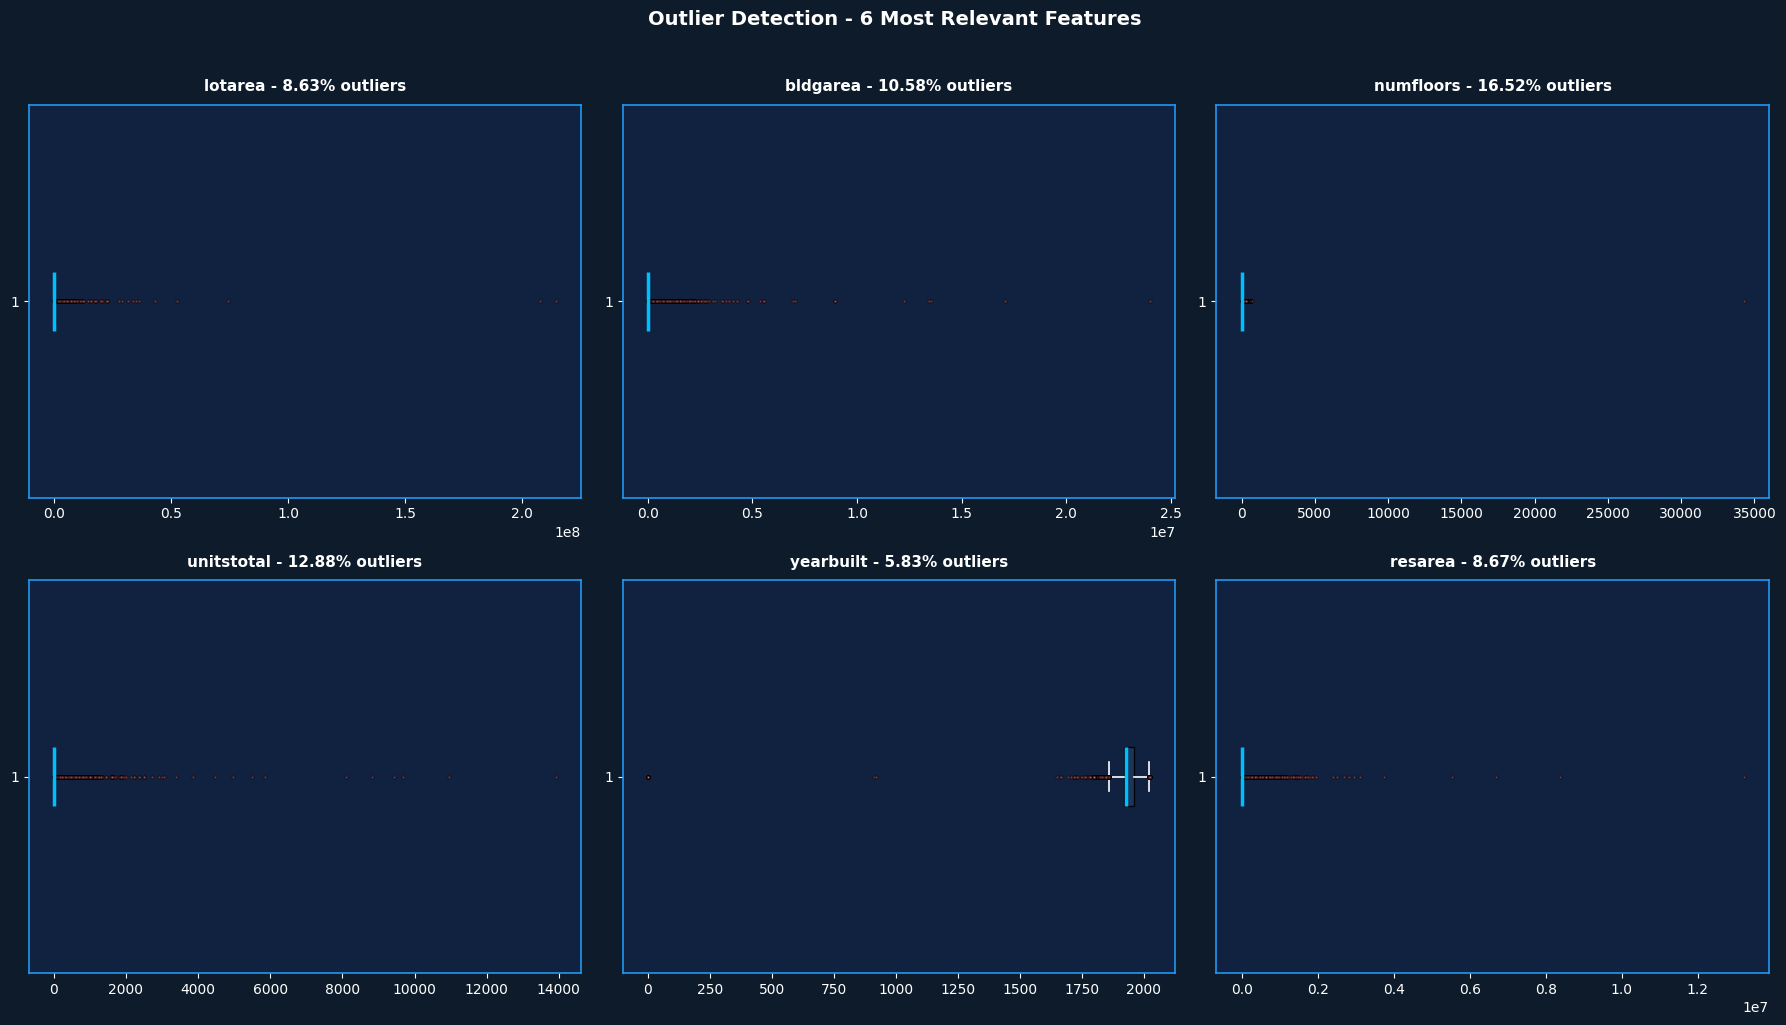

In [9]:
# ================================================
# BOXPLOTS - Dark blue theme for slides
# ================================================

most_relevant = [
    'lotarea', 'bldgarea', 'numfloors',
    'unitstotal', 'yearbuilt', 'resarea'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0D1B2A')
axes = axes.flatten()

for i, col in enumerate(most_relevant):
    axes[i].set_facecolor('#112240')
    axes[i].boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='#1E3A5F', alpha=0.9),
        medianprops=dict(color='#00BFFF', linewidth=2.5),
        whiskerprops=dict(color='white', linewidth=1.2),
        capprops=dict(color='white', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor='#FF6B6B',
                        markersize=2, alpha=0.4)
    )
    pct = outlier_table.loc[col, 'Outliers %']
    axes[i].set_title(f'{col} - {pct}% outliers',
                      fontsize=11, fontweight='bold', color='white', pad=10)
    axes[i].tick_params(colors='white')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#2196F3')
        spine.set_linewidth(1.2)

plt.suptitle('Outlier Detection - 6 Most Relevant Features',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/02_boxplots.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1B2A')
plt.show()

## Step 6 - Histograms: Raw vs Log1p

**Why histograms?**
Histograms show the shape of the distribution.
They prove visually why log transformation is necessary.

**What is log1p?**
`log1p(x) = log(x + 1)`
We use log1p instead of log because some values are exactly 0.
`log(0)` is mathematically undefined → would crash the code.
Adding 1 before the log solves this problem.

**Why these 4 features and not all 14?**
- `lotarea, bldgarea, numfloors, unitstotal` are the most skewed
  features that directly describe building size and density.
- `comarea, officearea` etc. → histogram is just a spike at 0, not informative
- `unitsres` → redundant with `unitstotal`
- `yearbuilt` → skewness of -4, no major problem
- `resarea` → similar pattern to `bldgarea`, would repeat the same message

**What to look for:**
- Red (RAW) → crushed against left axis → problem
- Green (LOG1P) → bell-shaped → ready for K-Means

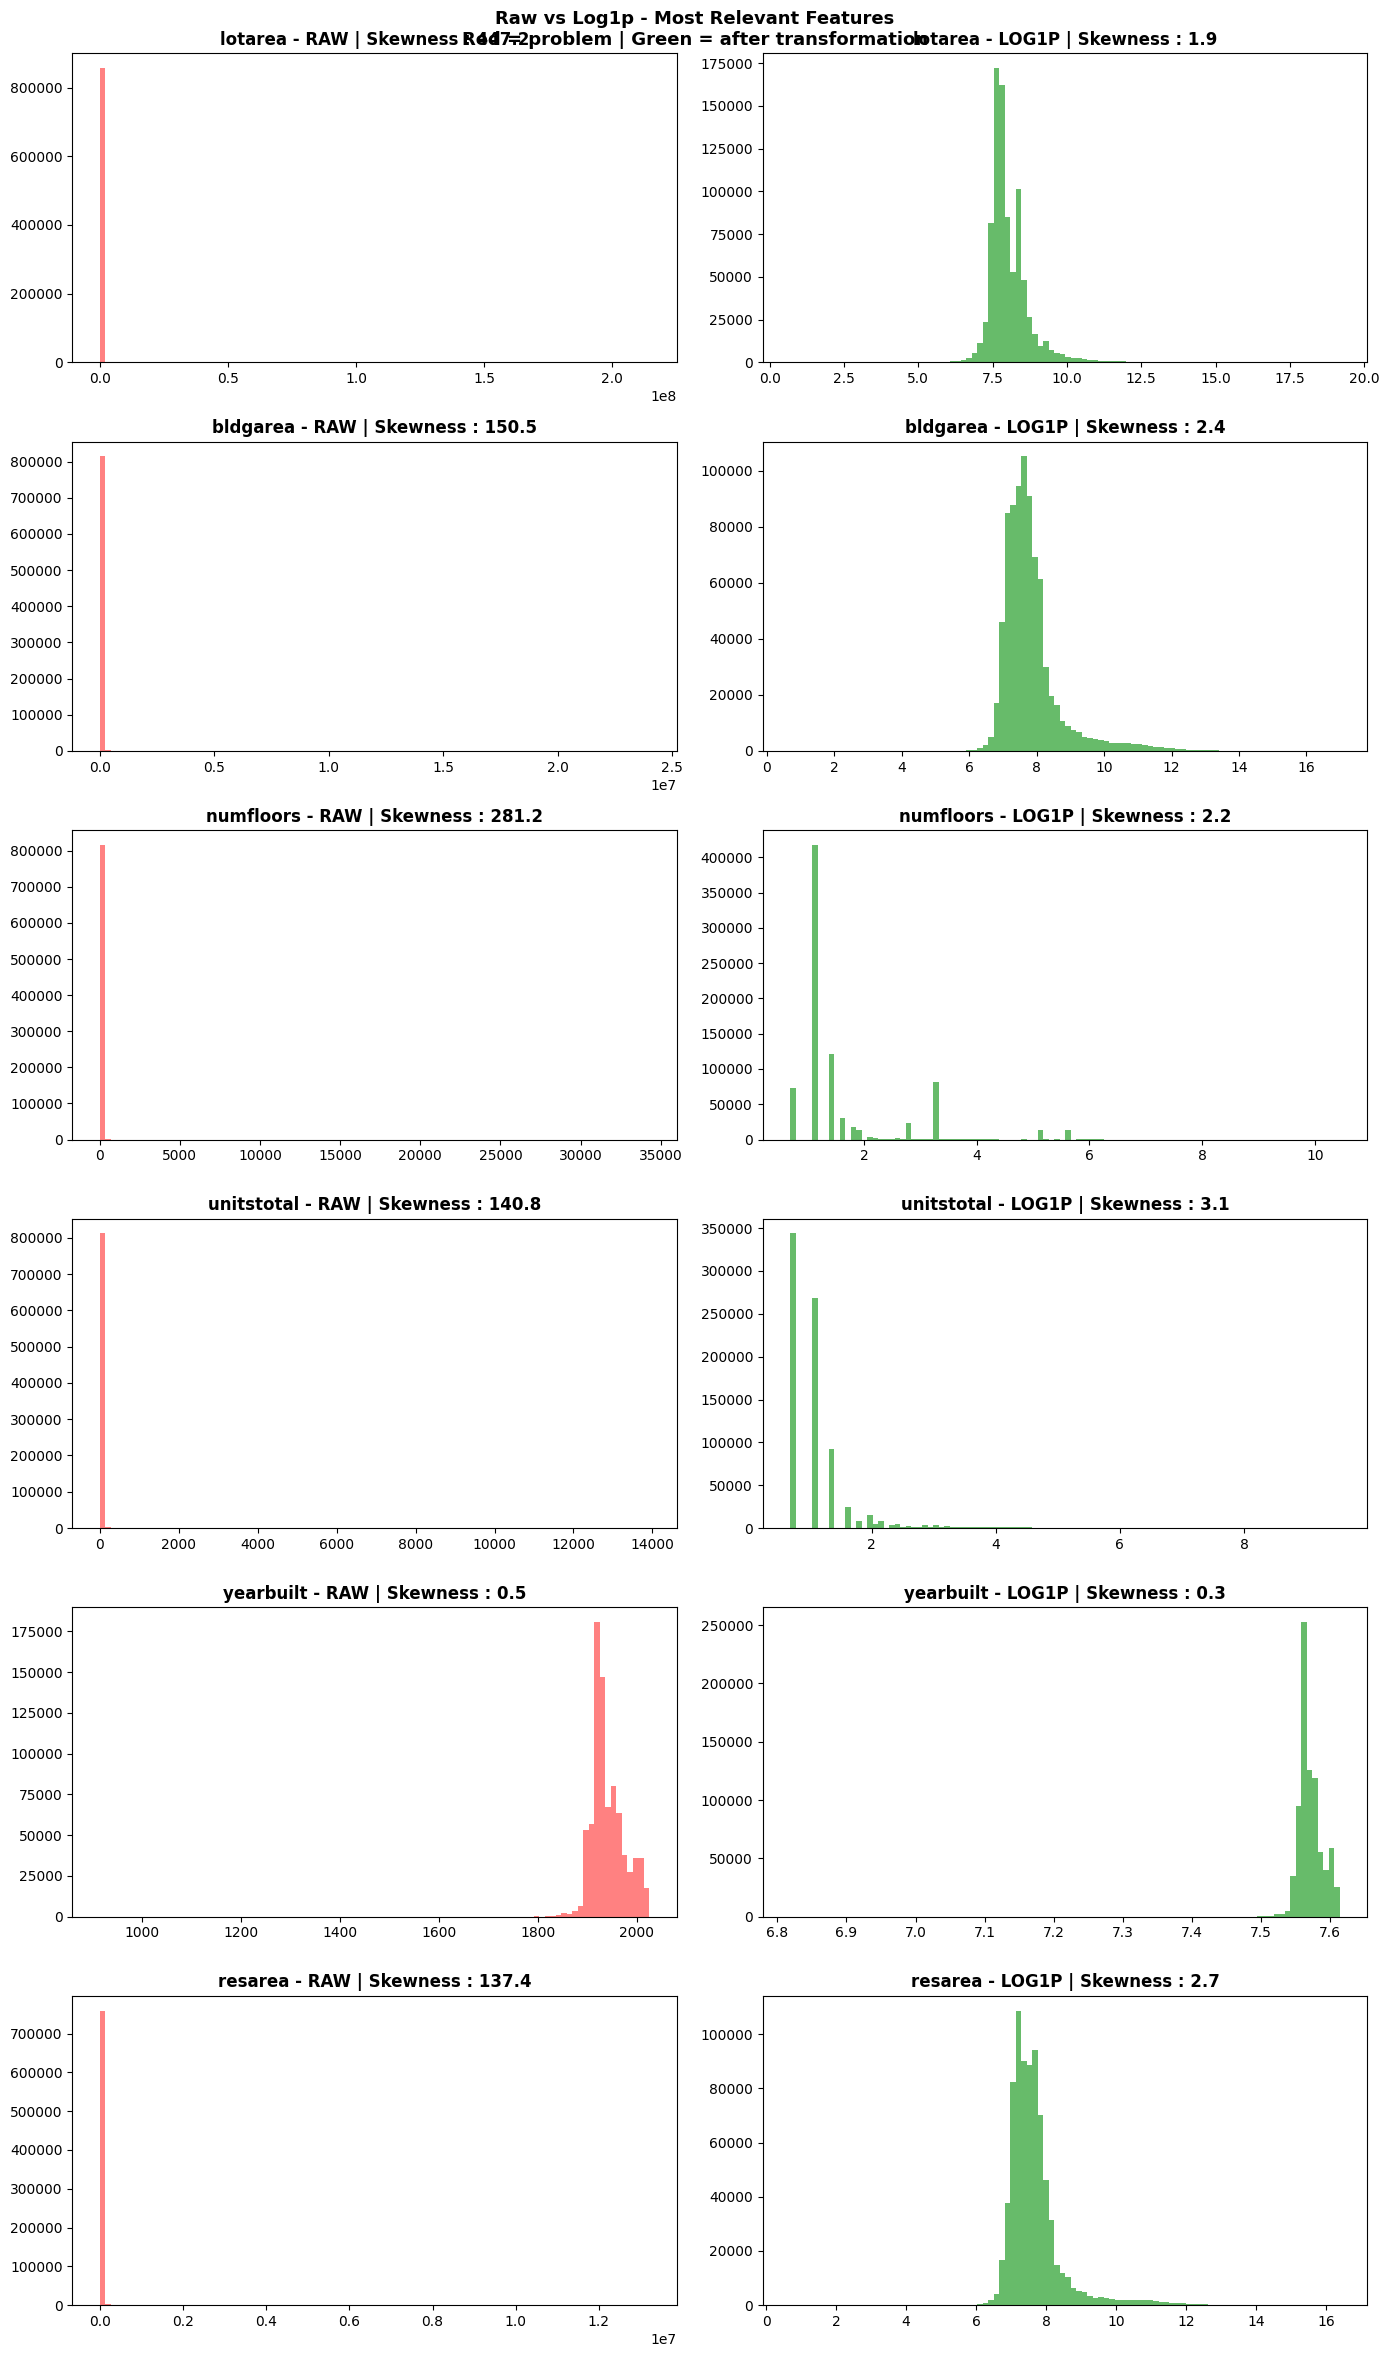

In [10]:
# ================================================
# HISTOGRAMS - Raw vs Log1p
# Most relevant features only
# ================================================

fig, axes = plt.subplots(6, 2, figsize=(14, 24))

for i, col in enumerate(most_relevant):
    data_raw = df[col].dropna()
    data_raw = data_raw[data_raw > 0]
    data_log = np.log1p(data_raw)

    # Raw
    axes[i, 0].hist(data_raw, bins=100,
                     color='#FF6B6B', edgecolor='none', alpha=0.85)
    axes[i, 0].set_title(
        f'{col} - RAW | Skewness : {round(data_raw.skew(), 1)}',
        fontweight='bold')

    # Log1p
    axes[i, 1].hist(data_log, bins=100,
                     color='#4CAF50', edgecolor='none', alpha=0.85)
    axes[i, 1].set_title(
        f'{col} - LOG1P | Skewness : {round(data_log.skew(), 1)}',
        fontweight='bold')

plt.suptitle(
    'Raw vs Log1p - Most Relevant Features\n'
    'Red = problem | Green = after transformation',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/02_histograms_raw_vs_log.png', dpi=150, bbox_inches='tight')
plt.show()

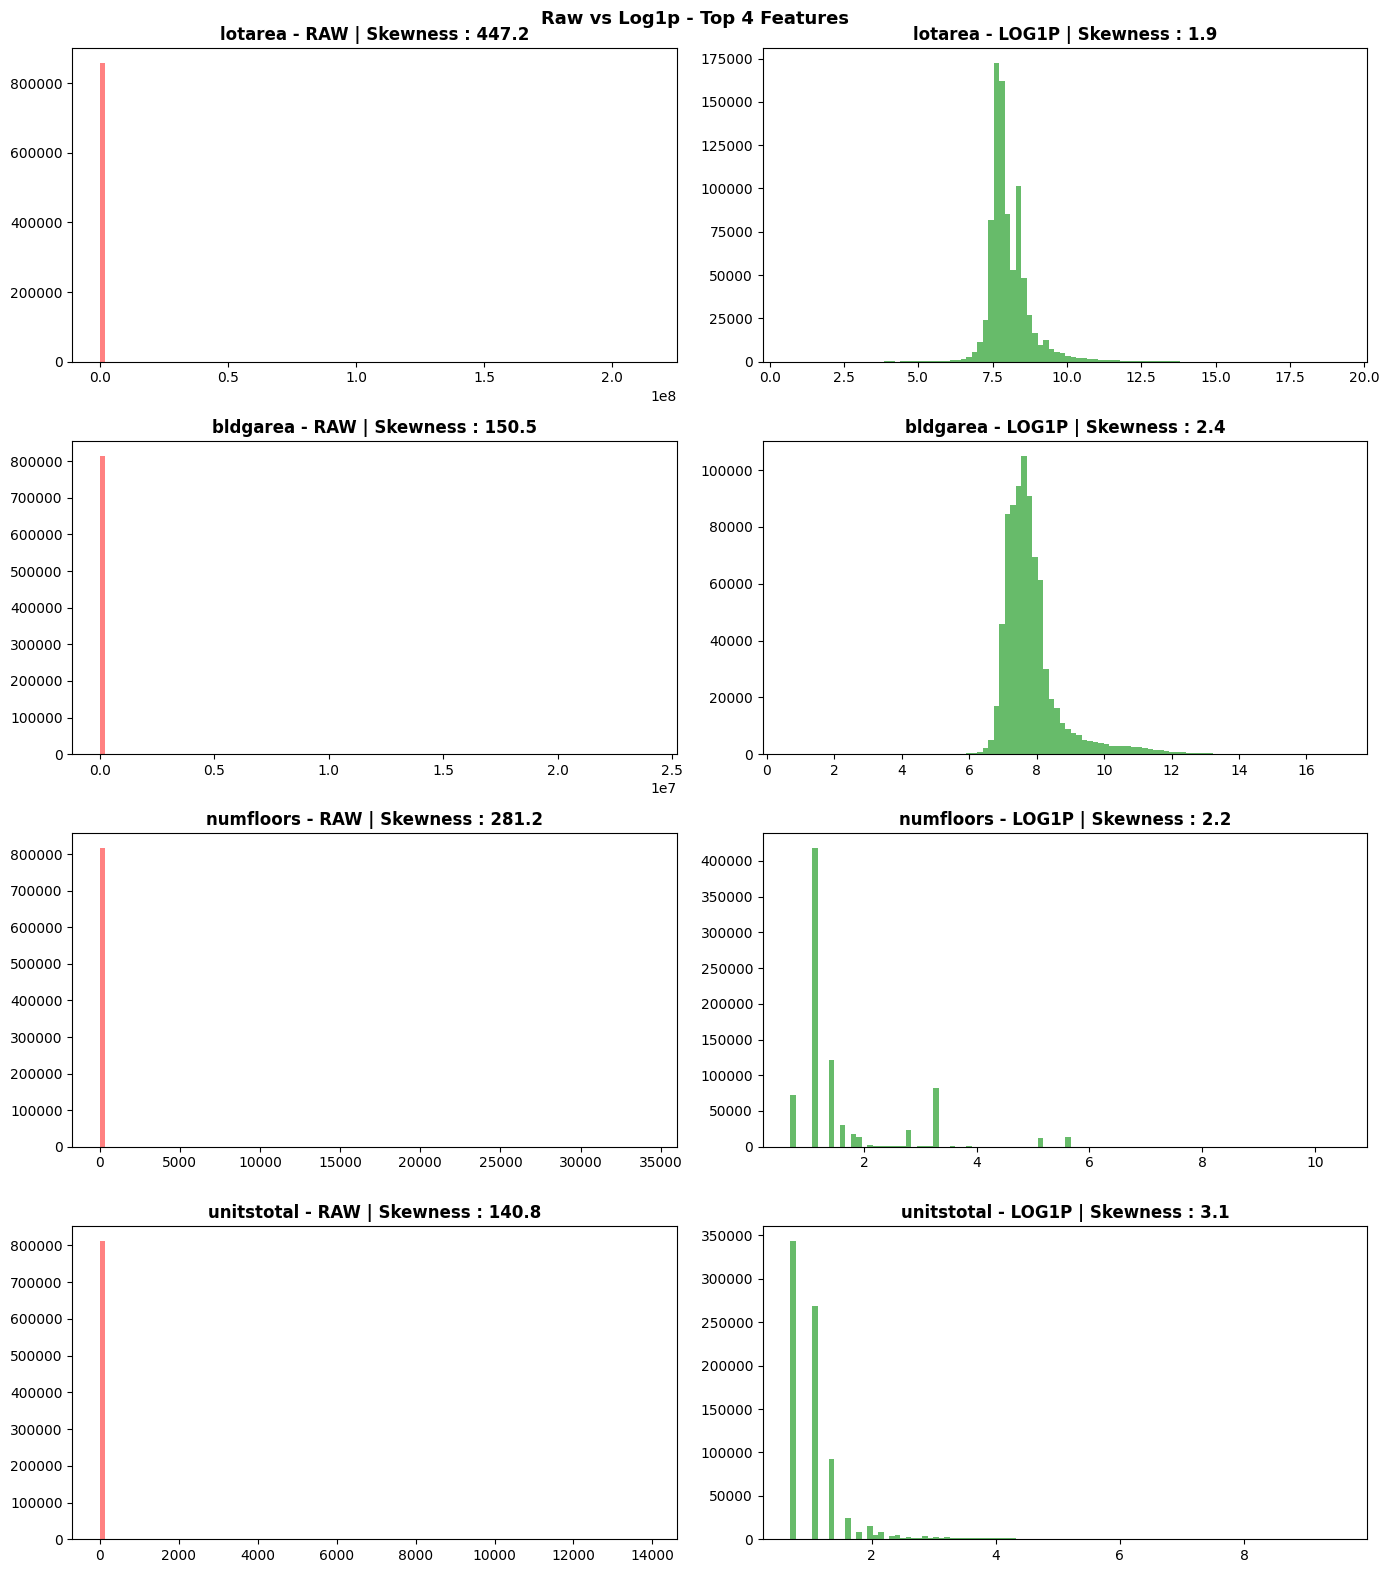

In [11]:
# ================================================
# HISTOGRAMS - Raw vs Log1p
# Top 4 most relevant features
# ================================================

top_features = [
    'lotarea',
    'bldgarea',
    'numfloors',
    'unitstotal'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for i, col in enumerate(top_features):
    data_raw = df[col].dropna()
    data_raw = data_raw[data_raw > 0]
    data_log = np.log1p(data_raw)

    axes[i, 0].hist(data_raw, bins=100,
                     color='#FF6B6B', edgecolor='none', alpha=0.85)
    axes[i, 0].set_title(
        f'{col} - RAW | Skewness : {round(data_raw.skew(), 1)}',
        fontweight='bold')

    axes[i, 1].hist(data_log, bins=100,
                     color='#4CAF50', edgecolor='none', alpha=0.85)
    axes[i, 1].set_title(
        f'{col} - LOG1P | Skewness : {round(data_log.skew(), 1)}',
        fontweight='bold')

plt.suptitle(
    'Raw vs Log1p - Top 4 Features',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/02_histograms_raw_vs_log.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 - Bar Plots: Categorical Features

**Why borough?**
Borough will NOT be used directly in K-Means.
If included, K-Means would create clusters based on administrative
boundaries instead of physical building characteristics.

Borough is kept for POST-CLUSTERING interpretation:
after finding clusters, we analyze how they distribute
across the 5 boroughs.

**Why landuse?**
`landuse` is the only categorical feature in our 15 selected variables.
The bar plot shows which categories dominate the dataset.
An imbalanced distribution can bias the encoding and clustering.
One-Hot Encoding will be applied to this feature in the preprocessing phase.

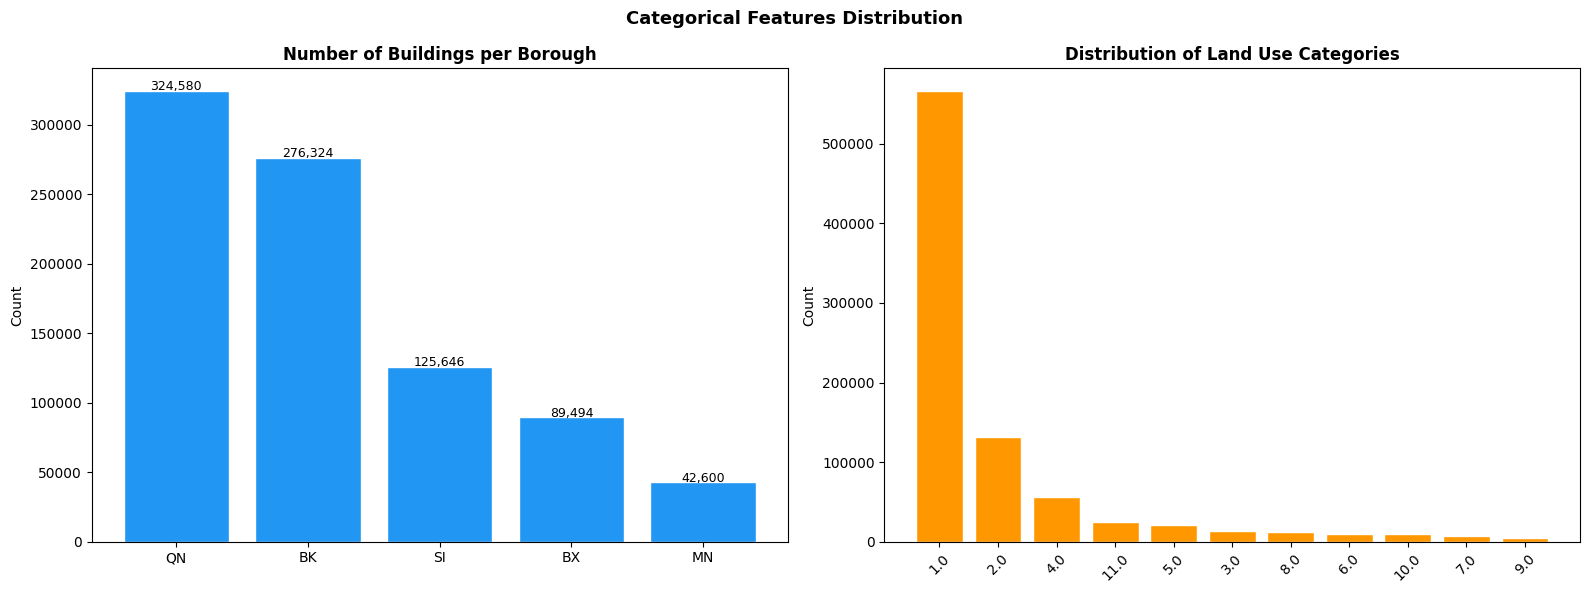

In [12]:
# ================================================
# BAR PLOTS - Categorical Features
# borough and landuse
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Borough ---
borough_counts = df['borough'].value_counts()
axes[0].bar(borough_counts.index, borough_counts.values,
             color='#2196F3', edgecolor='white')
axes[0].set_title('Number of Buildings per Borough',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, borough_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=9)

# --- Landuse ---
landuse_counts = df['landuse'].value_counts()
axes[1].bar(landuse_counts.index.astype(str),
             landuse_counts.values,
             color='#FF9800', edgecolor='white')
axes[1].set_title('Distribution of Land Use Categories',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/02_bar_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 - Scatter Plots

**Why scatter plots?**
Scatter plots show the relationship between two features.
They reveal whether a visual separation between building types
already exists in the raw data - which would suggest
K-Means can find meaningful clusters.

**Why log1p on the scatter plots?**
Without log1p, all points are crushed in the bottom-left corner.
The relationship between features is invisible.
After log1p, the real structure becomes visible.

**Why these 5 pairs?**
Each pair answers a specific question about NYC buildings:
- `lotarea` vs `bldgarea` → does a larger lot mean a larger building?
- `numfloors` vs `unitstotal` → more floors = more units?
- `resarea` vs `unitsres` → more residential area = more units?
- `lotfront` vs `lotdepth` → what is the typical lot geometry?
- `yearbuilt` vs `numfloors` → are modern buildings taller?

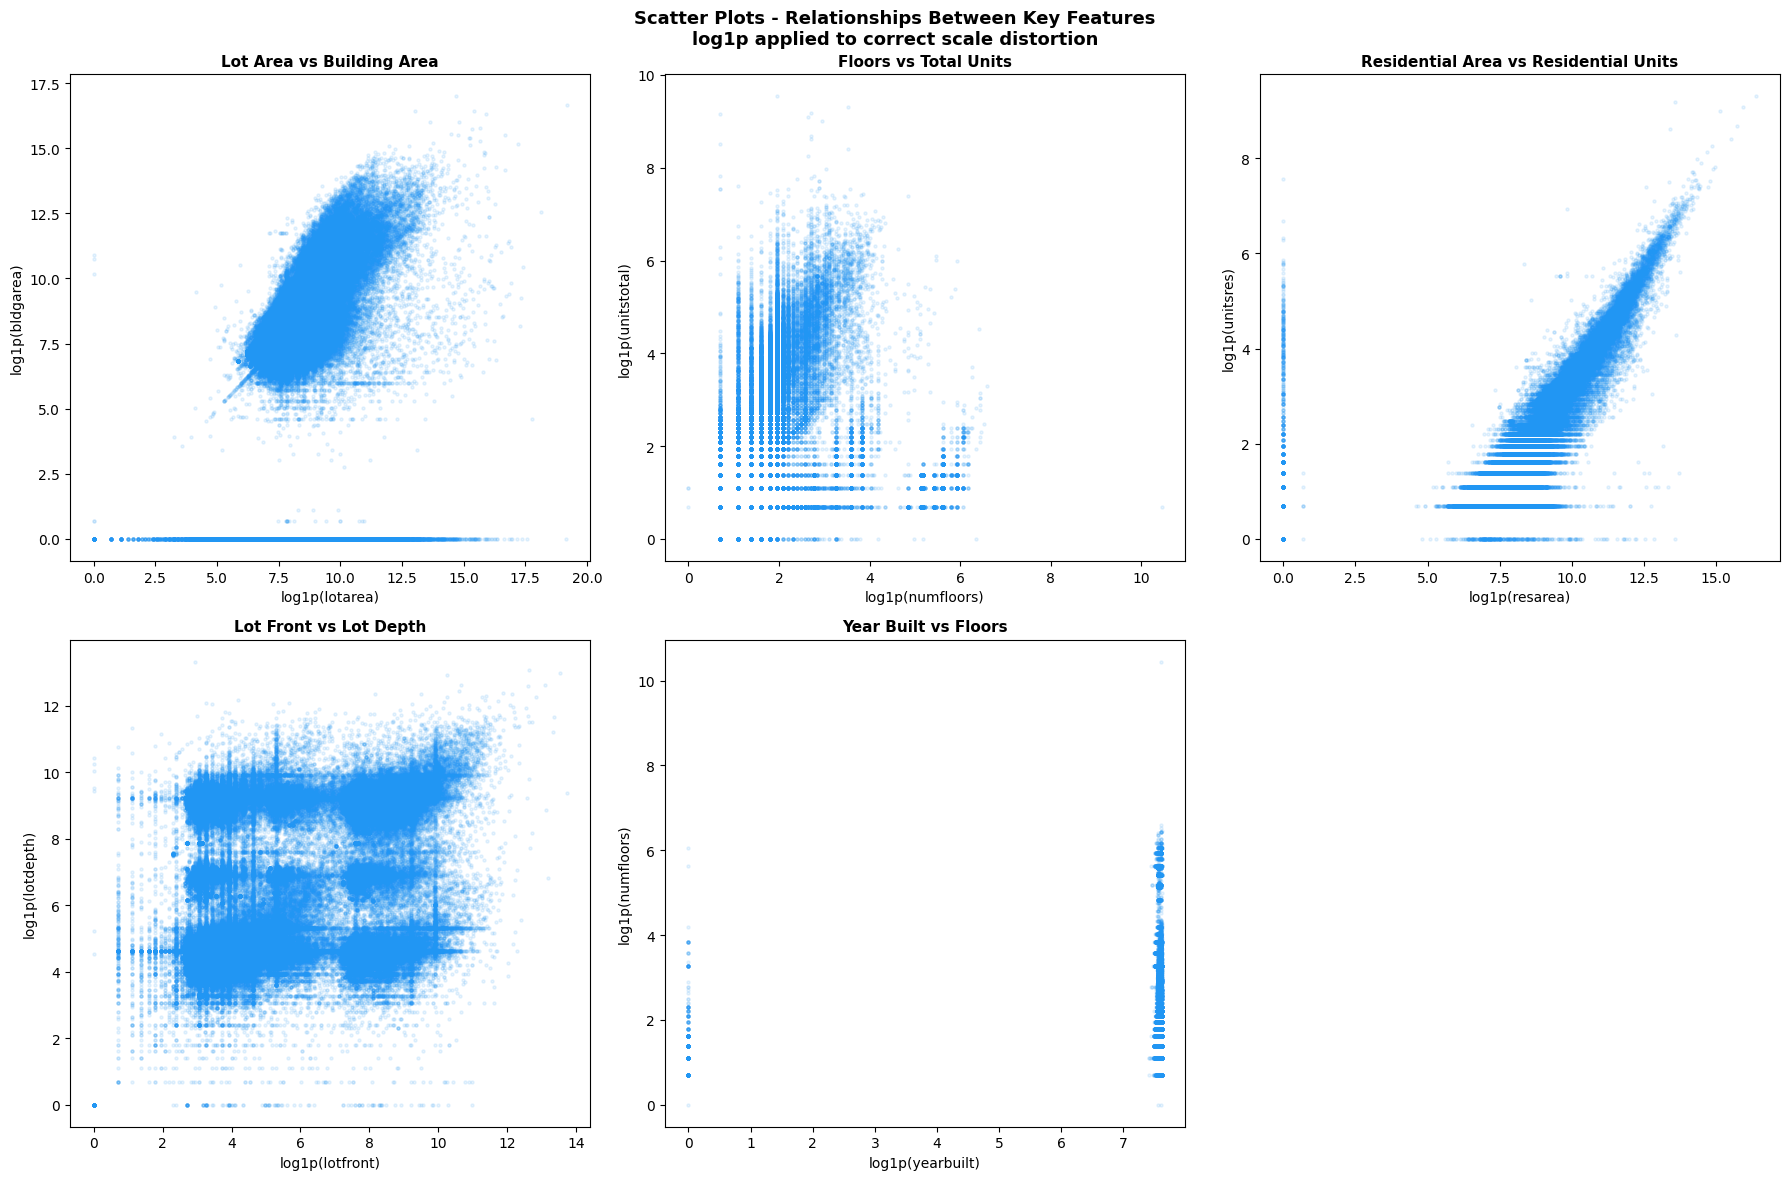

In [13]:
# ================================================
# SCATTER PLOTS - 5 pairs
# Using log1p to avoid scale distortion
# ================================================

pairs = [
    ('lotarea',   'bldgarea',   'Lot Area vs Building Area'),
    ('numfloors', 'unitstotal', 'Floors vs Total Units'),
    ('resarea',   'unitsres',   'Residential Area vs Residential Units'),
    ('lotfront',  'lotdepth',   'Lot Front vs Lot Depth'),
    ('yearbuilt', 'numfloors',  'Year Built vs Floors')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (x, y, title) in enumerate(pairs):
    axes[i].scatter(
        np.log1p(df[x]),
        np.log1p(df[y]),
        alpha=0.1, color='#2196F3', s=5
    )
    axes[i].set_title(title, fontweight='bold', fontsize=11)
    axes[i].set_xlabel(f'log1p({x})')
    axes[i].set_ylabel(f'log1p({y})')

# Hide the last empty subplot
axes[5].set_visible(False)

plt.suptitle('Scatter Plots - Relationships Between Key Features\n'
             'log1p applied to correct scale distortion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/02_scatter_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

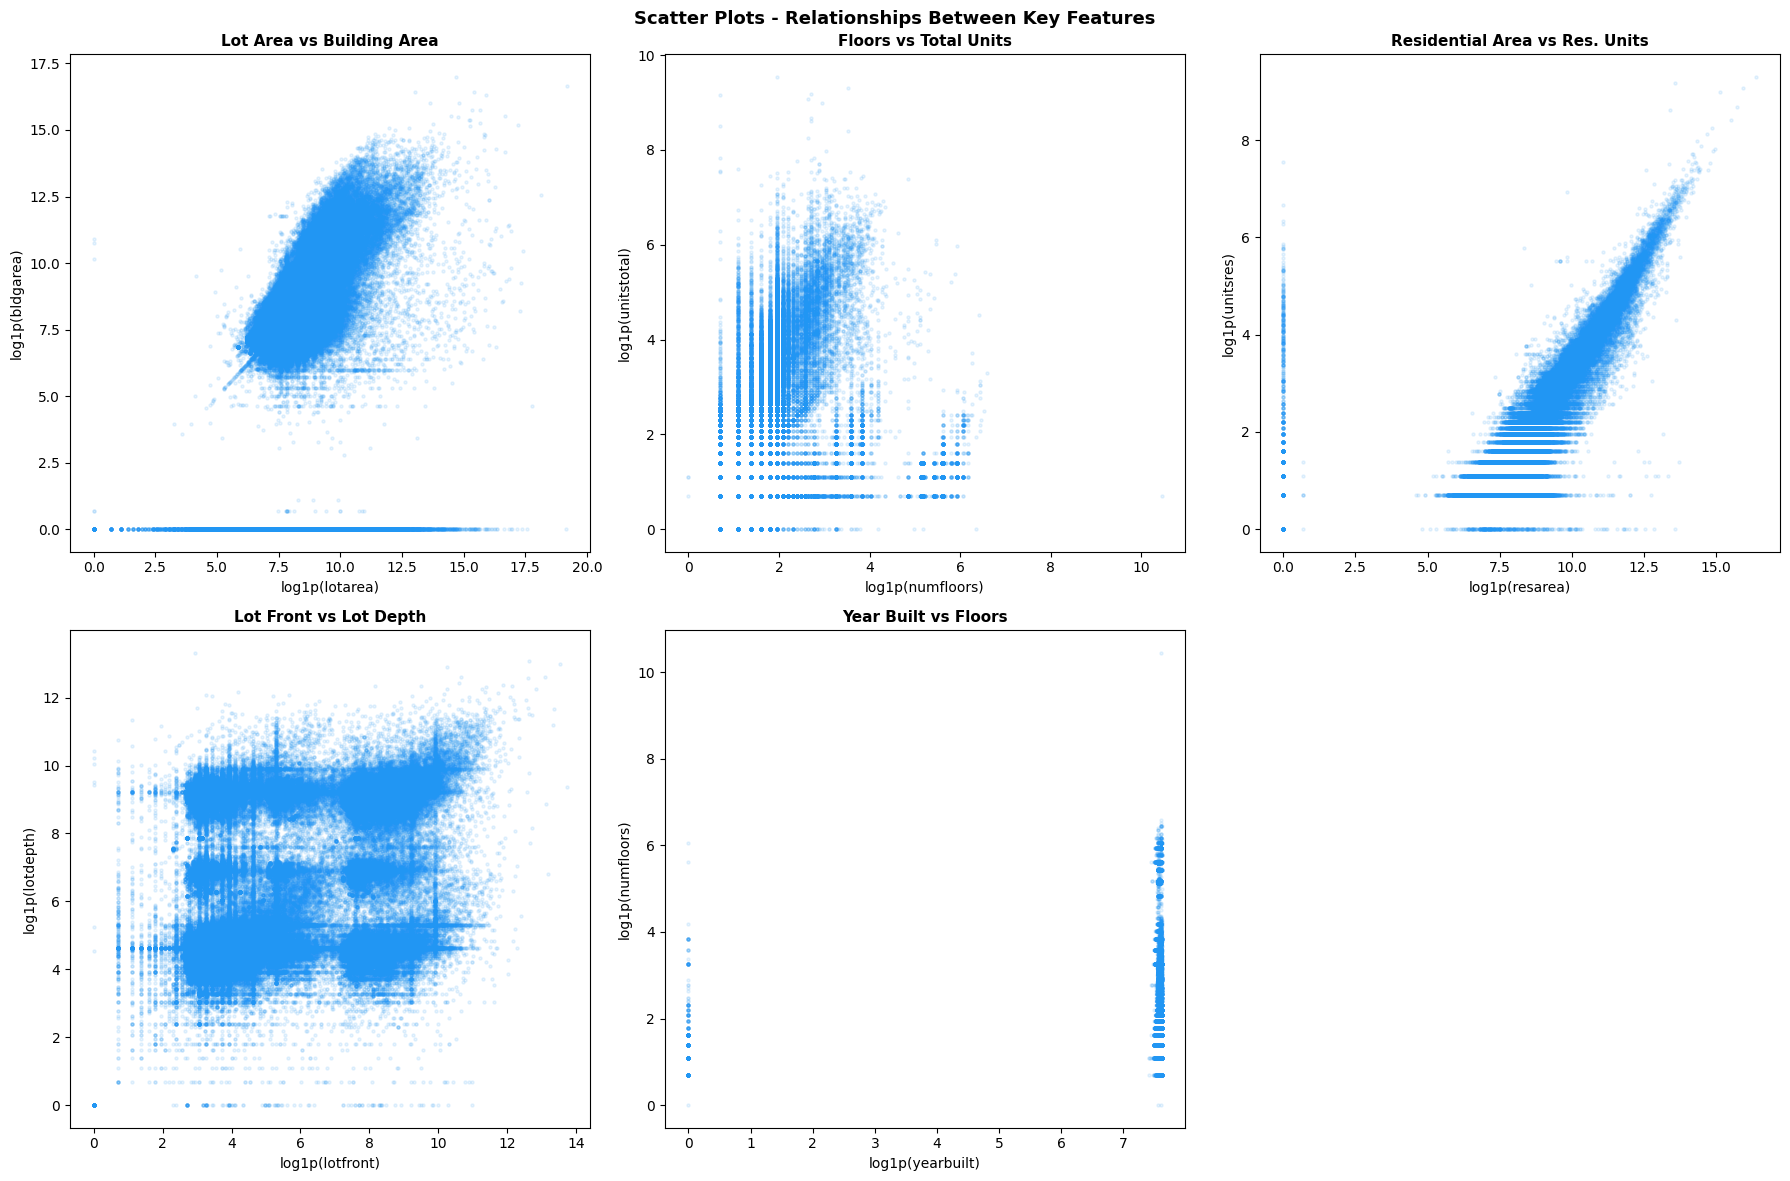

In [14]:
# ================================================
# SCATTER PLOTS - 5 relevant pairs
# ================================================

pairs = [
    ('lotarea',   'bldgarea',   'Lot Area vs Building Area'),
    ('numfloors', 'unitstotal', 'Floors vs Total Units'),
    ('resarea',   'unitsres',   'Residential Area vs Res. Units'),
    ('lotfront',  'lotdepth',   'Lot Front vs Lot Depth'),
    ('yearbuilt', 'numfloors',  'Year Built vs Floors')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (x, y, title) in enumerate(pairs):
    axes[i].scatter(
        np.log1p(df[x]),
        np.log1p(df[y]),
        alpha=0.1, color='#2196F3', s=5
    )
    axes[i].set_title(title, fontweight='bold', fontsize=11)
    axes[i].set_xlabel(f'log1p({x})')
    axes[i].set_ylabel(f'log1p({y})')

# Hide last empty subplot
axes[5].set_visible(False)

plt.suptitle('Scatter Plots - Relationships Between Key Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/02_scatter_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 - Correlation Heatmap

**What is Pearson correlation?**
A value between -1 and 1:
- Close to 1 → both features increase together
- Close to -1 → one increases when the other decreases  
- Close to 0 → no relationship

**Why only the lower triangle?**
The correlation matrix is symmetric.
Correlation(A,B) = Correlation(B,A).
Showing both triangles doubles the information without adding anything.

**Why redundancy is critical for K-Means:**
When two features correlate at 0.90, they carry the same information.
Including both gives that dimension double weight in distance calculations.
Clusters become dominated by one dimension instead of reflecting
the full diversity of building characteristics.

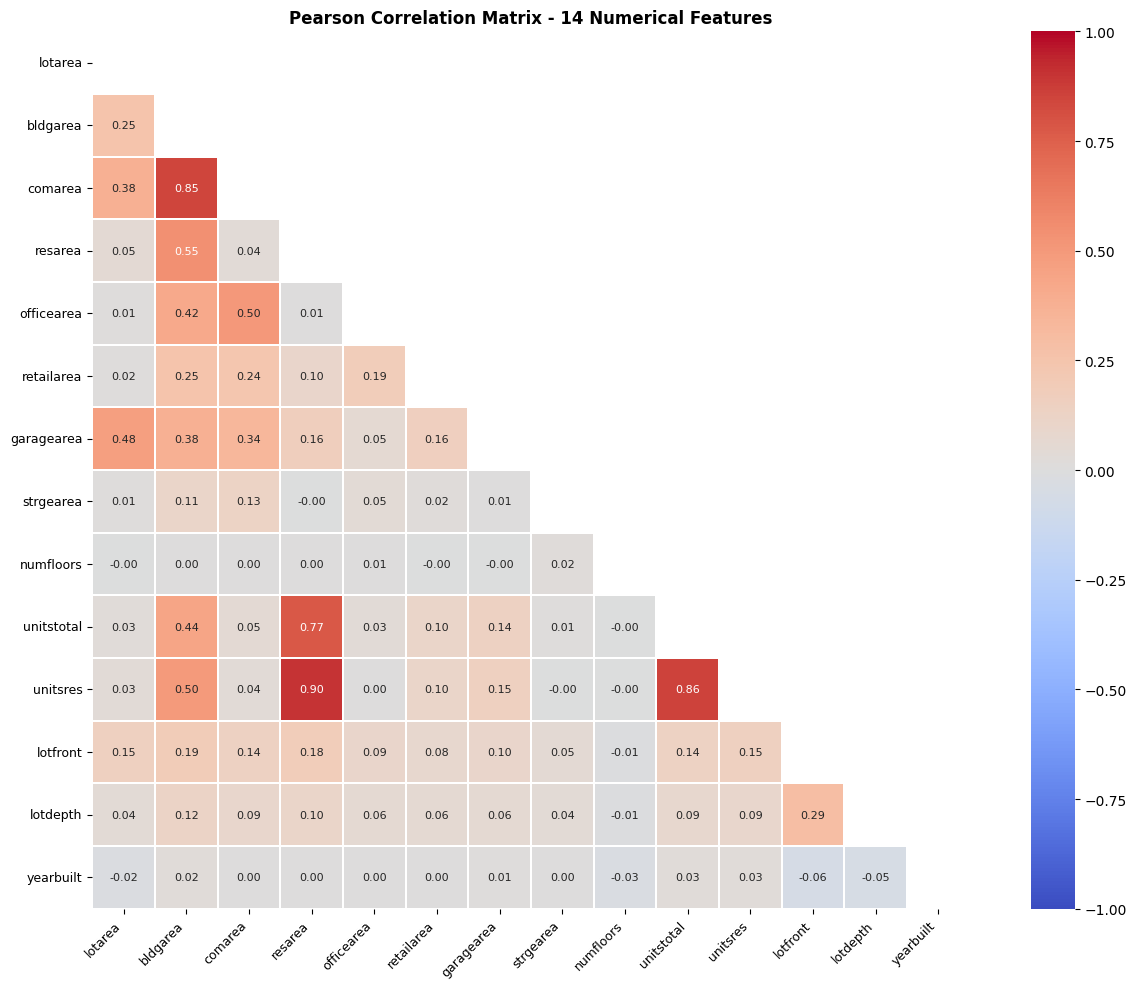


Pairs with correlation > 0.80 :
  comarea         ↔ bldgarea        : 0.85
  unitsres        ↔ resarea         : 0.90
  unitsres        ↔ unitstotal      : 0.86


In [15]:
# ================================================
# CORRELATION HEATMAP - 14 numerical features
# ================================================

plt.figure(figsize=(13, 10))

corr = df[numerical_features].corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 8}
)

plt.title('Pearson Correlation Matrix - 14 Numerical Features',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print strongly correlated pairs
print("\nPairs with correlation > 0.80 :")
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.80:
            print(f"  {corr.columns[i]:15s} ↔ "
                  f"{corr.columns[j]:15s} : "
                  f"{corr.iloc[i, j]:.2f}")

## Final Observations - Clusters, Separability and Anomalies

This step closes the visualization section.
After reviewing all graphs, we identify:
1. Visual separability between building types
2. All anomalies and unusual patterns detected

**Why this step is important:**
Every anomaly identified here has a direct consequence for K-Means.
Every observation justifies a specific preprocessing decision
that will be implemented in Section 6.

In [16]:
# ================================================
# SUMMARY OF ALL ANOMALIES DETECTED
# ================================================

print("===== ANOMALIES SUMMARY =====\n")

print("1. EXTREME SKEWNESS")
print("   lotarea=447, bldgarea=154, comarea=227")
print("   → log1p transformation required\n")

print("2. IMPOSSIBLE VALUES")
print("   yearbuilt=0 : 4.67% of rows")
print("   bldgarea=0  : 4.79% of rows")
print("   → Replace with NaN before K-Means\n")

print("3. HIGH REDUNDANCY")
print("   unitsres ↔ resarea    : 0.90")
print("   unitsres ↔ unitstotal : 0.86")
print("   → Drop one of each pair\n")

print("4. SCALE DIFFERENCES")
print("   lotarea up to 214M vs yearbuilt 1800-2026")
print("   → StandardScaler mandatory\n")

print("5. CATEGORICAL FEATURE")
print("   landuse cannot be used directly in K-Means")
print("   → One-Hot Encoding required")

===== ANOMALIES SUMMARY =====

1. EXTREME SKEWNESS
   lotarea=447, bldgarea=154, comarea=227
   → log1p transformation required

2. IMPOSSIBLE VALUES
   yearbuilt=0 : 4.67% of rows
   bldgarea=0  : 4.79% of rows
   → Replace with NaN before K-Means

3. HIGH REDUNDANCY
   unitsres ↔ resarea    : 0.90
   unitsres ↔ unitstotal : 0.86
   → Drop one of each pair

4. SCALE DIFFERENCES
   lotarea up to 214M vs yearbuilt 1800-2026
   → StandardScaler mandatory

5. CATEGORICAL FEATURE
   landuse cannot be used directly in K-Means
   → One-Hot Encoding required


## Implications for K-Means

The analysis reveals several issues that would strongly affect
distance-based clustering methods such as K-Means.

These features cannot be used directly in K-Means
without preprocessing due to skewness, outliers,
missing values and scale differences.

The next step will therefore require:
- log transformations,
- missing value handling,
- outlier treatment,
- feature scaling,
- categorical encoding.